In [ ]:
import matplotlib.pyplot as plt
import os
import kagglehub
import random
import cv2
import numpy as np
import shutil
import random
from glob import glob
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter
from skimage.feature import hog, local_binary_pattern
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import gabor
from skimage import measure
from imutils import contours
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report
)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Input, Conv2D, SeparableConv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator


Importamos las imágenes

In [ ]:
BASE_PATH = "../data"

train_path = os.path.join(BASE_PATH, "Train")
val_path   = os.path.join(BASE_PATH, "Val")
test_path  = os.path.join(BASE_PATH, "Test")

In [4]:
print(os.listdir(train_path))

['PNEUMONIA', 'NORMAL']


In [5]:
def load_dataset_paths(base_folder):
    paths = []
    labels = []

    for cls in ["NORMAL", "PNEUMONIA"]:
        cls_folder = os.path.join(base_folder, cls)
        for fname in os.listdir(cls_folder):
            img_path = os.path.join(cls_folder, fname)
            paths.append(img_path)
            labels.append(cls)
    return paths, labels


train_paths, train_labels = load_dataset_paths(train_path)
val_paths, val_labels     = load_dataset_paths(val_path)
test_paths, test_labels   = load_dataset_paths(test_path)

Creamos las funciones para extraer los descriptores clásicos de las imágenes y conformar el dataset.

In [6]:
def extract_hog_features(image, resize_dim=(256,256)):
    """
    Extrae los descriptores HOG de una imagen redimensionada.
    Retorna un vector de características que captura bordes y gradientes.
    """
    img = cv2.resize(image, resize_dim)
    features = hog(img, orientations=9, pixels_per_cell=(16,16),
                   cells_per_block=(2,2), block_norm='L2-Hys')
    return features

In [7]:
def extract_hu_moments(image):
    """
    Calcula los 7 momentos invariantes de Hu a partir de la imagen binaria.
    Devuelve un vector que captura forma independiente de escala, rotación y traslación.
    """
    moments = cv2.moments(image)
    hu = cv2.HuMoments(moments).flatten()
    return hu

In [8]:
def extract_contour_features(image):
    """
    Extrae características de contorno: área, perímetro y circularidad de la mayor región detectada.
    Devuelve 0s si no hay contornos.
    """
    ret, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
    cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(cnts) == 0:
        return [0, 0, 0]

    c = max(cnts, key=cv2.contourArea)

    area = cv2.contourArea(c)
    perimeter = cv2.arcLength(c, True)

    if perimeter == 0:
        circularity = 0
    else:
        circularity = 4*np.pi*(area/(perimeter**2))

    return [area, perimeter, circularity]

In [9]:
def extract_lbp_features(image, P=8, R=1):
    """
    Calcula el patrón LBP de la imagen y devuelve su histograma normalizado,
    capturando texturas locales mediante comparaciones de intensidad entre píxeles vecinos.
    """
    lbp = local_binary_pattern(image, P, R, method='uniform')
    hist, _ = np.histogram(lbp.ravel(),
                           bins=np.arange(0, P+3),
                           range=(0, P+2),
                           density=True)
    return hist

In [10]:
def extract_glcm_features(image):
    """
    Calcula la matriz GLCM de co-ocurrencia y extrae propiedades clásicas de textura
    como contraste, correlación, energía y homogeneidad.
    """
    glcm = graycomatrix(image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    features = [
        graycoprops(glcm, 'contrast')[0,0],
        graycoprops(glcm, 'correlation')[0,0],
        graycoprops(glcm, 'energy')[0,0],
        graycoprops(glcm, 'homogeneity')[0,0]
    ]
    return features

In [11]:
def extract_gabor_features(image, freq=0.6):
      """
    Aplica un filtro de Gabor para capturar textura en una frecuencia dada
    y devuelve estadísticas básicas (media y desviación estándar) de la respuesta.
    """
    filt_real, filt_imag = gabor(image, frequency=freq)
    return [filt_real.mean(), filt_real.std()]

In [12]:
def extract_all_features(image_path):
      """
    Extrae y concatena todos los descriptores clásicos (forma y textura)
    para construir el vector completo de características de una imagen.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    hog_feat = extract_hog_features(img)
    hu_feat = extract_hu_moments(img)
    cont_feat = extract_contour_features(img)
    lbp_feat = extract_lbp_features(img)
    glcm_feat = extract_glcm_features(img)
    gabor_feat = extract_gabor_features(img)

    features = np.concatenate([
        hog_feat,
        hu_feat,
        cont_feat,
        lbp_feat,
        glcm_feat,
        gabor_feat
    ])

    return features

In [13]:
def create_feature_matrix(split):
    """
    Construye la matriz de características (X) y el vector de etiquetas (y)
    para un subconjunto del dataset (Train, Val o Test). Recorre las carpetas
    de las clases, extrae todas las características de cada imagen y asigna
    su etiqueta correspondiente.
    """

    X = []
    y = []

    for label in ["NORMAL", "PNEUMONIA"]:
        folder = os.path.join(BASE_PATH, split, label)
        imgs = os.listdir(folder)

        for img_name in tqdm(imgs, desc=f"{split}-{label}"):
            img_path = os.path.join(folder, img_name)
            feats = extract_all_features(img_path)

            X.append(feats)
            y.append(0 if label=="NORMAL" else 1)

    return np.array(X), np.array(y)

Creamos los datasets con las features a partir de las imágenes.

In [ ]:
X_train, y_train = create_feature_matrix("Train")
X_val, y_val = create_feature_matrix("Val")
X_test, y_test = create_feature_matrix("Test")

Los alamacenamos para no tener que generar y guardar cada vez que se corre el código.

In [ ]:
np.save(BASE_PATH + "/X_train.npy", X_train)
np.save(BASE_PATH + "/y_train.npy", y_train)

np.save(BASE_PATH + "/X_val.npy", X_val)
np.save(BASE_PATH + "/y_val.npy", y_val)

np.save(BASE_PATH + "/X_test.npy", X_test)
np.save(BASE_PATH + "/y_test.npy", y_test)

Cargamos las imágenes.

In [15]:
X_train = np.load(BASE_PATH + "/X_train.npy")
y_train = np.load(BASE_PATH + "/y_train.npy")

X_val = np.load(BASE_PATH + "/X_val.npy")
y_val = np.load(BASE_PATH + "/y_val.npy")

X_test = np.load(BASE_PATH + "/X_test.npy")
y_test = np.load(BASE_PATH + "/y_test.npy")

In [16]:
print("X_train:", X_train.shape, " | y_train:", y_train.shape)
print("X_val:",   X_val.shape,   " | y_val:", y_val.shape)
print("X_test:",  X_test.shape,  " | y_test:", y_test.shape)

X_train: (4099, 8126)  | y_train: (4099,)
X_val: (878, 8126)  | y_val: (878,)
X_test: (879, 8126)  | y_test: (879,)


Con esto generamos 4 set datos, uno para train, uno para validación y otro para test. En total son 8126 features. Se va probar modelos de ML clásicos de clasificación y un modelo de CNN. Dependiendo de los resultados y las métricas obtenidas, se evalua si es necesario aplicar PCA.

Para los modelos de ML clásicos como no es obligatorio tener un set de validación y otro de test, se unen los sets de train y validación, y se deja el set de test para evaluar las métricas en datos nuevos.

In [17]:
# Fusionar training + validation
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

# El test lo dejamos intacto
X_test_final = X_test
y_test_final = y_test

In [18]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import numpy as np

Se crean los pipelines de los modelos, aplicando Estandarización.

In [19]:
modelos = {
    "SVM (Lineal)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", probability=True))
    ]),

    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", probability=True))
    ]),

    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(n_estimators=200))
    ]),

    "k-NN (k=5)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=200))
    ])
}


Se ajustan los modelos y se evaluan sus métricas.


Entrenando: SVM (Lineal)
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       238
           1       0.97      0.96      0.97       641

    accuracy                           0.95       879
   macro avg       0.94      0.94      0.94       879
weighted avg       0.95      0.95      0.95       879



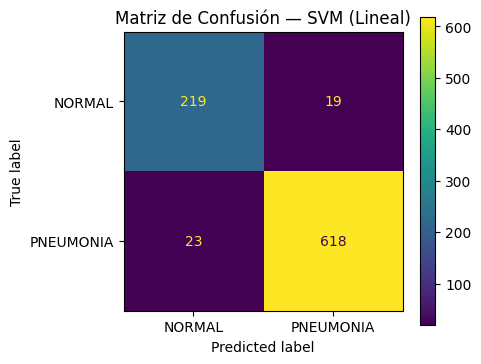

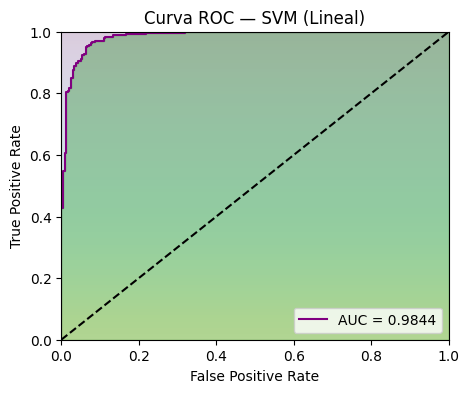


Entrenando: SVM (RBF)
              precision    recall  f1-score   support

           0       0.94      0.91      0.93       238
           1       0.97      0.98      0.97       641

    accuracy                           0.96       879
   macro avg       0.95      0.94      0.95       879
weighted avg       0.96      0.96      0.96       879



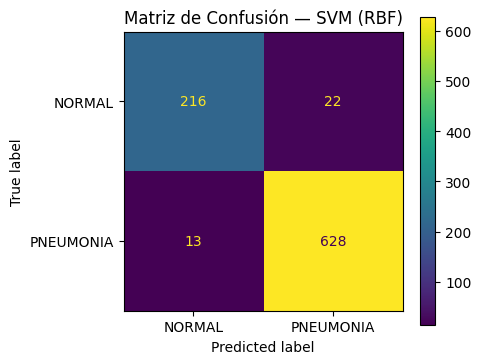

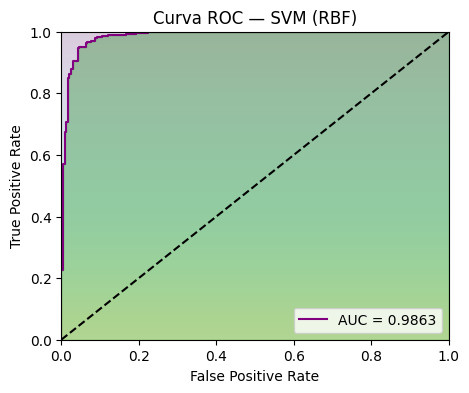


Entrenando: Random Forest
              precision    recall  f1-score   support

           0       0.91      0.84      0.87       238
           1       0.94      0.97      0.96       641

    accuracy                           0.93       879
   macro avg       0.93      0.90      0.91       879
weighted avg       0.93      0.93      0.93       879



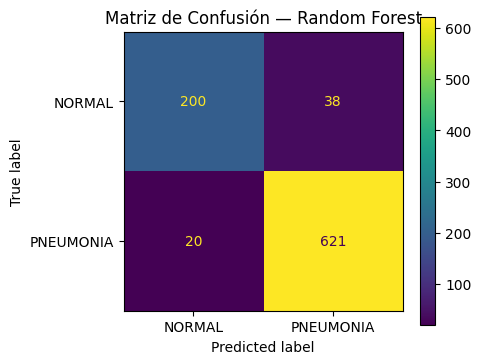

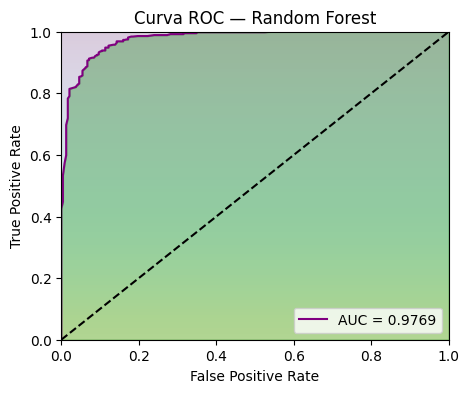


Entrenando: k-NN (k=5)
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       238
           1       0.96      0.96      0.96       641

    accuracy                           0.94       879
   macro avg       0.93      0.93      0.93       879
weighted avg       0.94      0.94      0.94       879



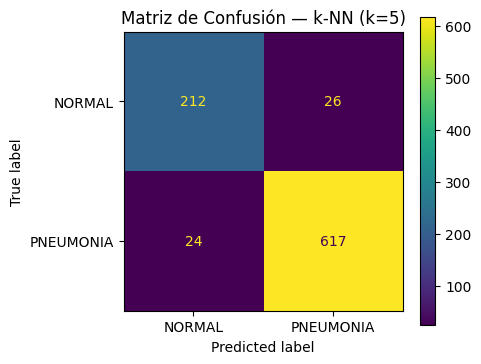

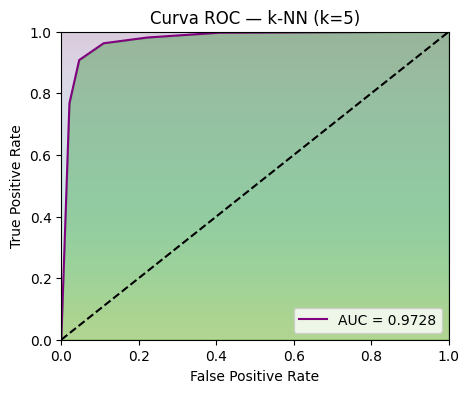


Entrenando: Logistic Regression
              precision    recall  f1-score   support

           0       0.88      0.92      0.90       238
           1       0.97      0.95      0.96       641

    accuracy                           0.95       879
   macro avg       0.93      0.94      0.93       879
weighted avg       0.95      0.95      0.95       879



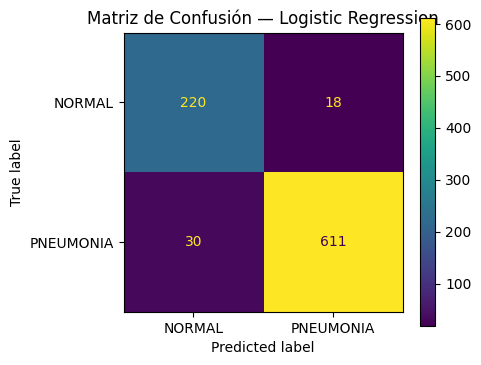

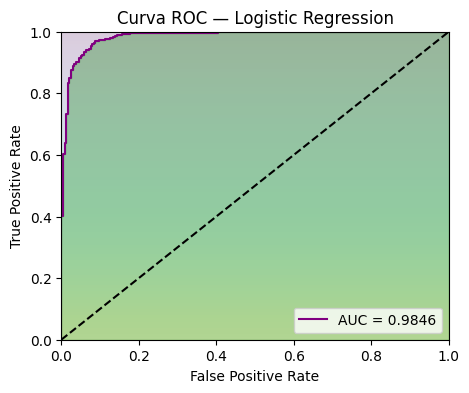

In [22]:
plt.style.use('default')  # evita estilos que cambian colores

resultados = {}

for nombre, modelo in modelos.items():
    print("\n==============================")
    print(f"Entrenando: {nombre}")

    modelo.fit(X_train_full, y_train_full)
    preds = modelo.predict(X_test_final)

    # ------- Métricas numéricas -------
    acc = accuracy_score(y_test_final, preds)
    prec = precision_score(y_test_final, preds, pos_label=1)
    rec = recall_score(y_test_final, preds, pos_label=1)
    f1 = f1_score(y_test_final, preds, pos_label=1)

    resultados[nombre] = {
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    }

    print(classification_report(y_test_final, preds))

    #Matriz de confusión

    cm = confusion_matrix(y_test_final, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])

    fig, ax = plt.subplots(figsize=(4.5, 4))
    disp.plot(ax=ax, cmap="viridis", colorbar=True)
    plt.title(f"Matriz de Confusión — {nombre}")
    plt.show()

    # Curva ROC
    if hasattr(modelo, "predict_proba"):
        y_scores = modelo.predict_proba(X_test_final)[:, 1]
    else:
        y_scores = modelo.decision_function(X_test_final)

    fpr, tpr, _ = roc_curve(y_test_final, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color="purple")  # línea
    plt.fill_between(fpr, tpr, alpha=0.3, color="green")  # opcional

    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"Curva ROC — {nombre}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    # Fondo viridis
    plt.imshow(
        np.outer(np.linspace(0, 1, 100), np.ones(100)),
        extent=[0, 1, 0, 1],
        cmap="viridis",
        alpha=0.2,
        aspect='auto'
    )

    plt.legend()
    plt.show()

Los resultados muestran un desempeño sobresaliente en todos los modelos, con accuracies entre 93% y 96%, indicando una alta capacidad para diferenciar entre NORMAL y PNEUMONIA. El SVM con kernel RBF es el mejor, logrando 96% de accuracy y excelente balance entre recall y precision, especialmente en la clase 1 (PNEUMONIA). El SVM lineal también ofrece métricas muy competitivas, apenas un poco por debajo del RBF. k-NN y Logistic Regression mantienen desempeños estables alrededor del 94–95%, confirmando que las características extraídas permiten buena separabilidad. El Random Forest, aunque sólido, es el menos preciso para la clase NORMAL, lo que lo ubica ligeramente por debajo del resto. En general, todos los modelos detectan muy bien los casos de neumonía (clase 1), con recalls cercanos al 96–98%. La clase NORMAL es más difícil de clasificar, pero aun así mantiene métricas altas. La consistencia entre los modelos sugiere que el conjunto de características LBP + Gabor + estadísticas está bien construido. Finalmente, el SVM RBF sería la mejor elección para producción por su equilibrio entre desempeño y estabilidad.

Como oportunidad de mejora, se podría enfocar en mejorar el dataset con la clase NORMAL, ya que como se evidencio en el preprocesamiento, hay un desbalanceo con esa clase.

Probamos con una CNN

Se configura generadores de imágenes para entrenamiento, validación y prueba usando Keras. Se define un ImageDataGenerator con aumentación (rotaciones, desplazamientos, zoom, flips) para mejorar la generalización del modelo. Todas las imágenes se redimensionan a 128×128 y se escalan a valores entre 0 y 1. Finalmente, se crean los generadores que cargan las imágenes desde carpetas organizadas por clases, en lotes de 16 y con etiquetas binarias.

In [11]:
IMG_SIZE = (128,128)
BATCH = 16

In [12]:
datagen = ImageDataGenerator(
    rescale=1/255.0,
    rotation_range=15,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
)

test_datagen = ImageDataGenerator(rescale=1/255.0)

train_gen = datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary'
)

val_gen = test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary'
)

test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='binary',
    shuffle=False
)

Found 4099 images belonging to 2 classes.
Found 878 images belonging to 2 classes.
Found 879 images belonging to 2 classes.


Utilizamos SeparableConv2D, una variante de las convoluciones estándar que reduce drásticamente los parámetros separando la convolución espacial y la de profundidad (similar al enfoque de MobileNet). La arquitectura sigue un esquema clásico: bloques de SeparableConv2D + BatchNorm + MaxPooling que extraen características progresivamente más abstractas. Al final, se aplanan las características y pasan por capas densas con Dropout para evitar sobreajuste, finalizando en una salida sigmoidal para clasificación binaria.

In [15]:
def build_light_cnn():
    inp = Input(shape=(128,128,3))

    x = SeparableConv2D(16, (3,3), activation='relu', padding='same')(inp)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)

    x = SeparableConv2D(32, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)

    x = SeparableConv2D(64, (3,3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D(2)(x)

    x = Flatten()(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    out = Dense(1, activation='sigmoid')(x)

    model = Model(inp, out)
    return model

model = build_light_cnn()
model.summary()


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 128, 128, 16)   │            91 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 64, 64, 32)     │           688 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_2              │ (None, 32, 32, 64)     │         2,400 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     1,048,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,052,332 (4.01 MB)

 Trainable params: 1,052,108 (4.01 MB)

 Non-trainable params: 224 (896.00 B)

Utilizamos EarlyStopping que detiene el proceso si el modelo deja de mejorar para evitar sobreajuste y recupera los mejores pesos, mientras que ReduceLROnPlateau reduce automáticamente la tasa de aprendizaje cuando el rendimiento se estanca, ayudando al modelo a afinar mejor sus mínimos.

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.3)
]

Entrenamos.

In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 1878s 7s/step - accuracy: 0.8005 - loss: 0.6644 - val_accuracy: 0.7301 - val_loss: 2.1628 - learning_rate: 0.0010
Epoch 2/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 38s 149ms/step - accuracy: 0.8986 - loss: 0.2465 - val_accuracy: 0.8144 - val_loss: 0.5567 - learning_rate: 0.0010
Epoch 3/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 38s 147ms/step - accuracy: 0.9179 - loss: 0.2137 - val_accuracy: 0.9237 - val_loss: 0.1940 - learning_rate: 0.0010
Epoch 4/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 38s 147ms/step - accuracy: 0.9316 - loss: 0.1952 - val_accuracy: 0.9579 - val_loss: 0.1356 - learning_rate: 0.0010
Epoch 5/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 37s 146ms/step - accuracy: 0.9242 - loss: 0.2045 - val_accuracy: 0.9522 - val_loss: 0.1074 - learning_rate: 0.0010
Epoch 6/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 37s 143ms/step - accuracy: 0.9268 - loss: 0.1964 - val_accuracy: 0.9476 - val_loss: 0.1533 - learning_rate: 0.0010
Epoch 7/20
257/257 ━━━━━━━━━━━━━━━━━━━━ 39s 153ms/step - accuracy: 0.93

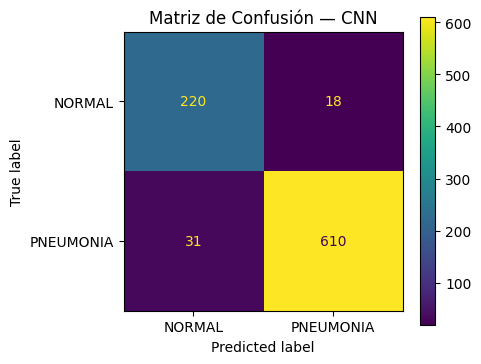

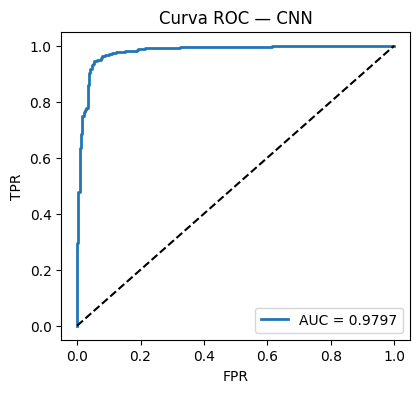

In [20]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["NORMAL", "PNEUMONIA"])

fig, ax = plt.subplots(figsize=(4.5, 4))
disp.plot(ax=ax, cmap="viridis", colorbar=True)
plt.title("Matriz de Confusión — CNN")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4.5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", linewidth=2)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Curva ROC — CNN")
plt.legend()
plt.show()

De los resultados obtenidos por la CNN no se ve una gran mejora con respecto a los modelos de ML tradicionales, aunque sus métricas siendo "buenas".

Como conclusión general el modelo que presenta las métricas más favorables, para el contexto del problema es la máquina de soporte vectorial con kernel RBF (Radial Basis Function), ya que presenta el menor error en los Falsos Negativos, ya que es crítico porque, la neumonía requiere atención rápida; si no se detecta, el paciente puede empeorar, tener complicaciones graves o incluso morir. El tratamiento se retrasa y puede generar más contagio si es infecciosa. En el otro caso. En cambio, decir que una persona tiene neumonía cuando no la tiene (falso positivo) es molesto y genera costos adicionales (radiografía, antibióticos innecesarios, ansiedad) pero no pone en riesgo inmediato la vida del paciente.